Training set shape: (53, 21)
Validation set shape: (11, 22)

FEATURES FOR ANALYSIS (13)
 1. TFACTOR
 2. AWS100
 3. AWS25
 4. DEP2WATTBL
 5. SLOPE_1
 6. CM2RESLYR
 7. KFACTWS
 8. PHWATER
 9. CLAY
10. KSAT
11. OM
12. SAND
13. Land_Cover_Encoded

✓ All features found in both datasets

DATASET SUMMARY

TRAINING SET:

  Runoff P-Sourced Riparian (n=12)
  Sites: Central Cemetery, Millbury, Elizabeth Br, Stow, Lowell Rd bridge, Concord, Mill River, River Rd, Wayland, Route 122A, Grafton, Rte 20, Wayland, Rte 225, Bedford, Rte 62, Acton, Trout Brook, Ware River, West River

  Stabilizing TP Riparian (n=17)
  Sites: Assabet River, Cady Brook, French River, Maynard St, Westboro, Mill Road, Westboro, Millers River, Nashoba Brook, Nashoba, Wheeler Ln, Acton, Otter River, Quinebaug River, Quinsigamond River, Robin Hill Rd, Marlboro, Rte 62, Stow, Rte 9, Westboro, Sudbury Landing, Framingham, Sudbury River, UBWPAD &amp; Blackston River

  Stable Soil Riparian (n=15)
  Sites: Concord River, Danforth 

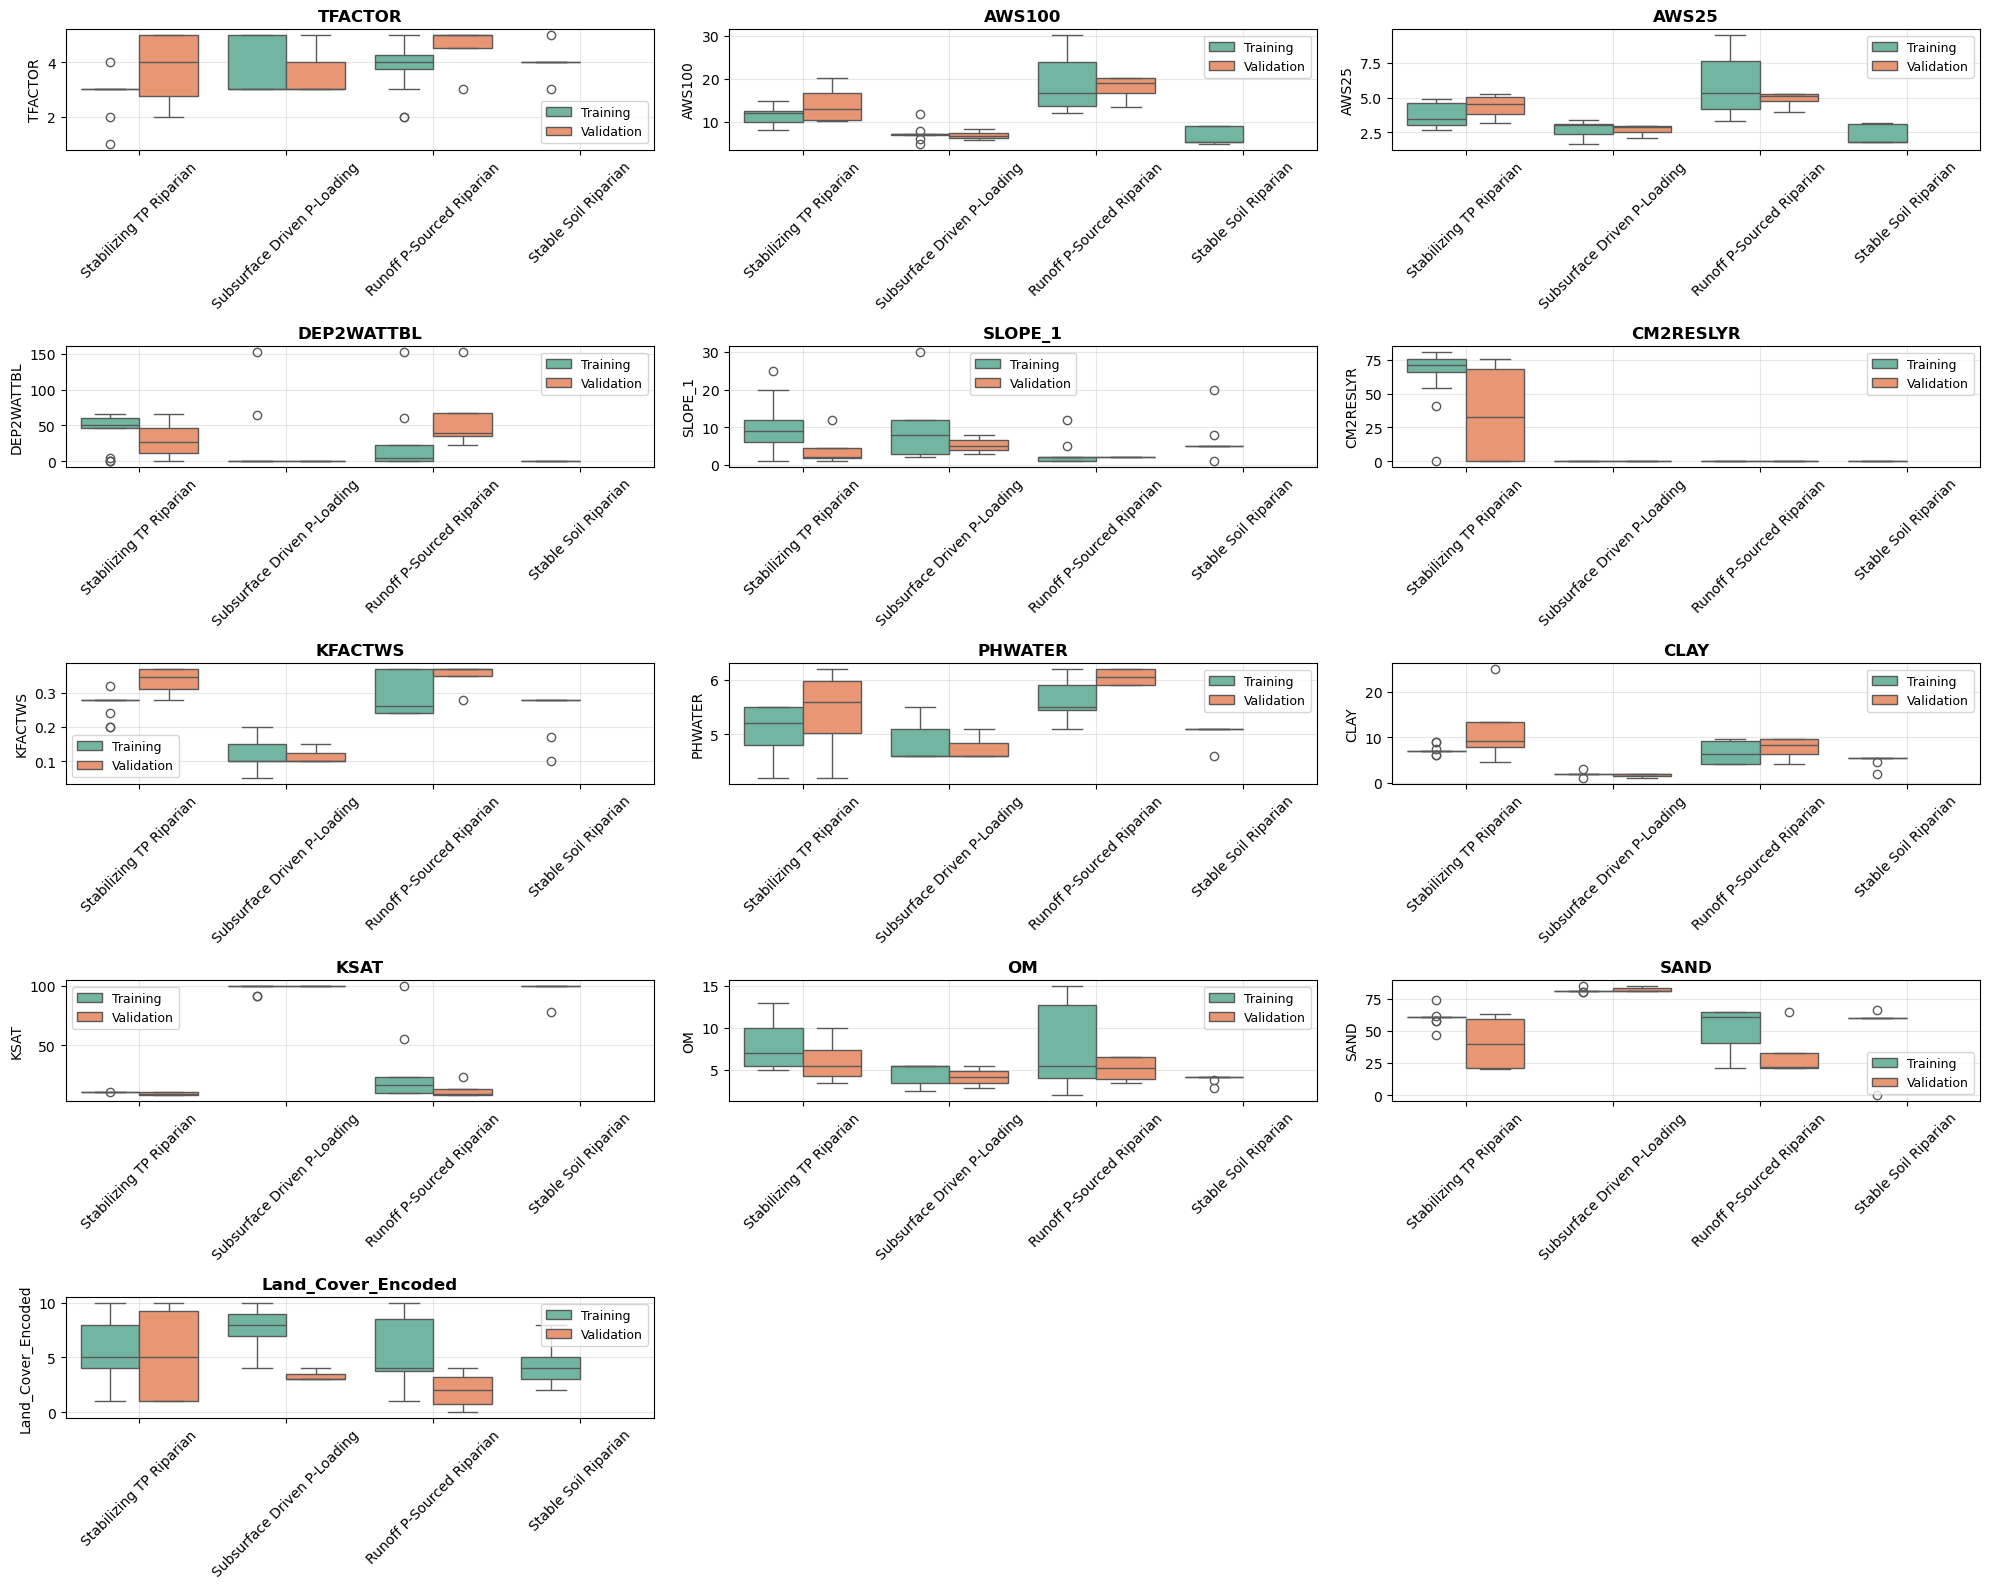

Generating distribution visualizations...
✓ Saved: riparian_distributions_13features.png


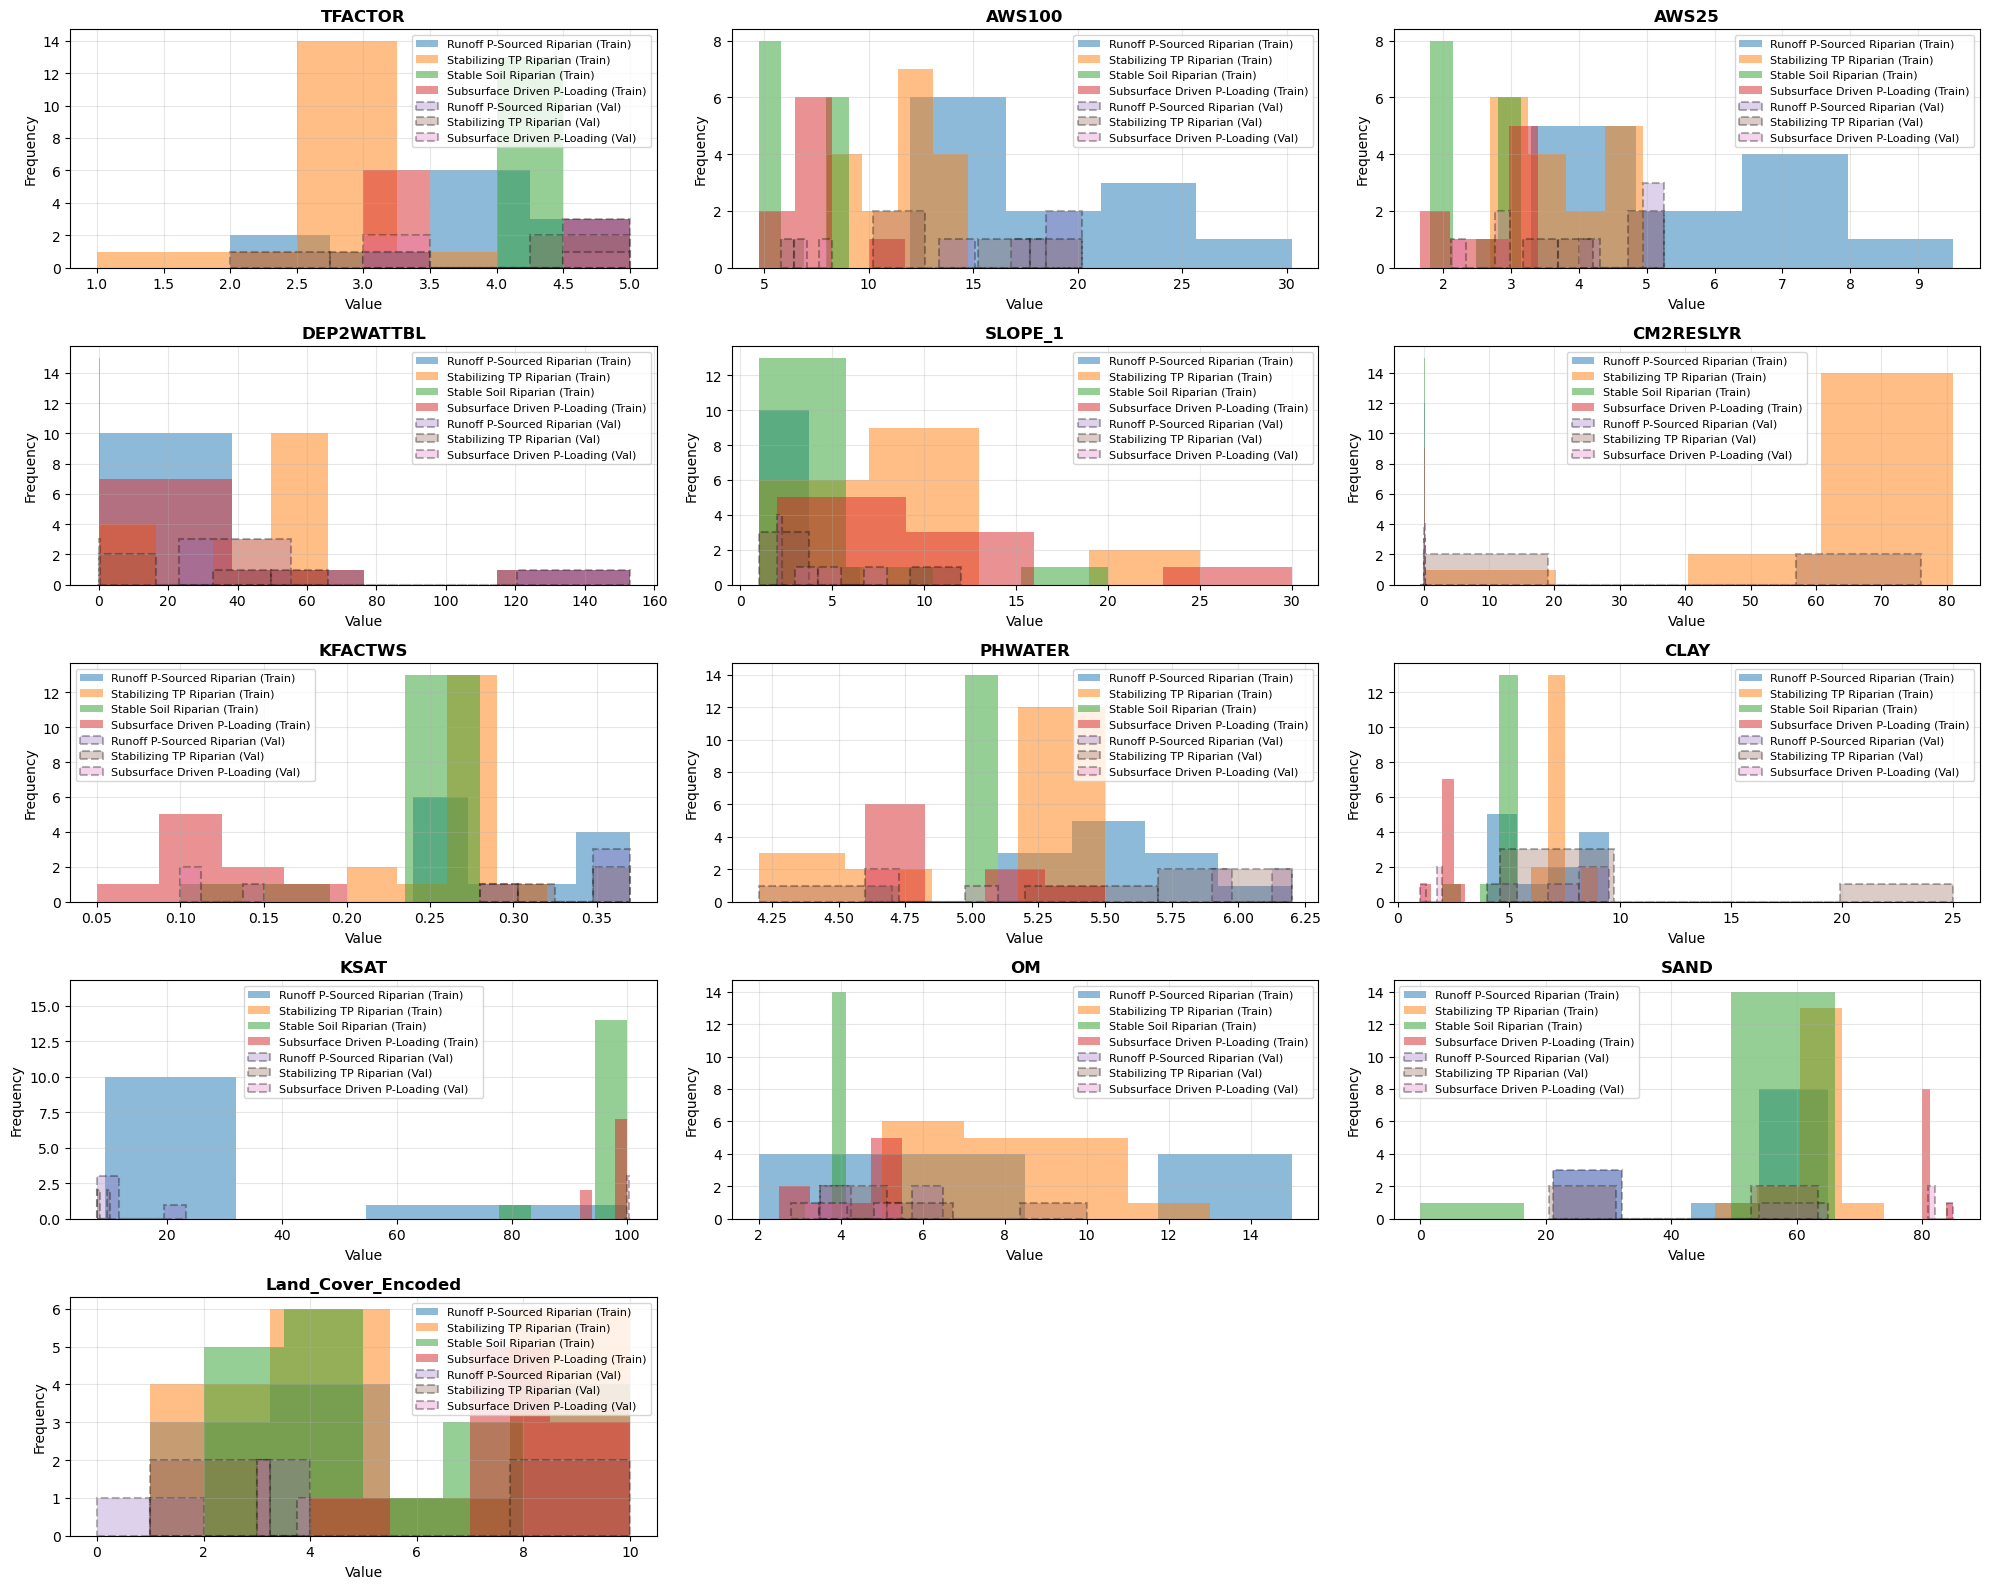


STATISTICAL COMPARISON: Mann-Whitney U Test (non-parametric)
p < 0.05 indicates SIGNIFICANT DIFFERENCE between training and validation


Runoff P-Sourced Riparian
----------------------------------------------------------------------------------------------------------------------------------
Feature              Train N  Train Mean      Val N    Val Mean        p-value      Result                        
----------------------------------------------------------------------------------------------------------------------------------
TFACTOR              12       3.833           4        4.500           0.2231       ✓ Not significant             
AWS100               12       18.707          4        17.900          1.0000       ✓ Not significant             
AWS25                12       5.822           4        4.875           0.6701       ✓ Not significant             
DEP2WATTBL           12       24.250          4        63.500          0.0514       ✓ Not significant             

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ============================================================================
# LOAD DATA
# ============================================================================

# Load both datasets
train_df = pd.read_csv('typology-training-labeled.csv')
val_df = pd.read_csv('validation-labeled.csv')

print("Training set shape:", train_df.shape)
print("Validation set shape:", val_df.shape)

# ============================================================================
# DEFINE FEATURES TO ANALYZE
# ============================================================================

# Exact features requested (mapping to actual column names in data)
features_to_analyze = [
    'TFACTOR',
    'AWS100',
    'AWS25',
    'DEP2WATTBL',
    'SLOPE_1',        # "Soil slope" in data
    'CM2RESLYR',
    'KFACTWS',
    'PHWATER',
    'CLAY',
    'KSAT',
    'OM',
    'SAND',
    'Land_Cover_Encoded'  # "LC" in data
]

print(f"\n{'='*80}")
print(f"FEATURES FOR ANALYSIS ({len(features_to_analyze)})")
print(f"{'='*80}")
for i, feature in enumerate(features_to_analyze, 1):
    print(f"{i:2d}. {feature}")

# Verify all features exist
missing_train = [f for f in features_to_analyze if f not in train_df.columns]
missing_val = [f for f in features_to_analyze if f not in val_df.columns]

if missing_train or missing_val:
    print(f"\n⚠ WARNING:")
    if missing_train:
        print(f"  Missing from training: {missing_train}")
    if missing_val:
        print(f"  Missing from validation: {missing_val}")
else:
    print("\n✓ All features found in both datasets")

# ============================================================================
# SUMMARY: SITES BY RIPARIAN TYPE
# ============================================================================

print(f"\n{'='*80}")
print("DATASET SUMMARY")
print(f"{'='*80}\n")

print("TRAINING SET:")
for riparian_type in sorted(train_df['Type'].unique()):
    subset = train_df[train_df['Type'] == riparian_type]
    print(f"\n  {riparian_type} (n={len(subset)})")
    print(f"  Sites: {', '.join(subset['MonitoringLocationName'].tolist())}")

print("\n" + "-"*80)
print("\nVALIDATION SET:")
for riparian_type in sorted(val_df['Type'].unique()):
    subset = val_df[val_df['Type'] == riparian_type]
    print(f"\n  {riparian_type} (n={len(subset)})")
    print(f"  Sites: {', '.join(subset['MonitoringLocationName'].tolist())}")

# ============================================================================
# DETAILED FEATURE RANGES BY TYPE
# ============================================================================

def get_feature_ranges(df, dataset_name, features):
    """Get min-max-mean-std ranges for features by riparian type"""
    
    print(f"\n{'='*120}")
    print(f"{dataset_name.upper()} - COMPLETE FEATURE STATISTICS BY RIPARIAN TYPE")
    print(f"{'='*120}\n")
    
    results = {}
    
    for riparian_type in sorted(df['Type'].unique()):
        subset = df[df['Type'] == riparian_type]
        print(f"\n{riparian_type} (n={len(subset)})")
        print("-" * 120)
        print(f"{'Feature':<20} {'Min':<12} {'Max':<12} {'Mean':<12} {'Std':<12} {'Range':<12}")
        print("-" * 120)
        
        type_results = {}
        for col in features:
            if col in subset.columns:
                min_val = subset[col].min()
                max_val = subset[col].max()
                mean_val = subset[col].mean()
                std_val = subset[col].std()
                range_val = max_val - min_val
                
                type_results[col] = {
                    'min': min_val,
                    'max': max_val,
                    'mean': mean_val,
                    'std': std_val,
                    'range': range_val,
                    'count': len(subset)
                }
                
                print(f"{col:<20} {min_val:<12.2f} {max_val:<12.2f} {mean_val:<12.2f} {std_val:<12.2f} {range_val:<12.2f}")
        
        results[riparian_type] = type_results
    
    return results

train_ranges = get_feature_ranges(train_df, "TRAINING", features_to_analyze)
val_ranges = get_feature_ranges(val_df, "VALIDATION", features_to_analyze)

# ============================================================================
# SIDE-BY-SIDE COMPARISON TABLE (DETAILED)
# ============================================================================

def compare_ranges_detailed(train_ranges, val_ranges, features):
    """Create detailed side-by-side comparison"""
    
    print(f"\n{'='*150}")
    print("DETAILED TRAINING vs. VALIDATION COMPARISON")
    print(f"{'='*150}\n")
    
    all_types = sorted(set(list(train_ranges.keys()) + list(val_ranges.keys())))
    
    for riparian_type in all_types:
        print(f"\n{'='*150}")
        print(f"{riparian_type}")
        print(f"{'='*150}")
        print(f"{'Feature':<20} {'TRAINING (Min-Max)':<35} {'VALIDATION (Min-Max)':<35} {'Difference':<60}")
        print("-" * 150)
        
        if riparian_type in train_ranges and riparian_type in val_ranges:
            train_type = train_ranges[riparian_type]
            val_type = val_ranges[riparian_type]
            
            for feature in features:
                if feature in train_type:
                    train_min = train_type[feature]['min']
                    train_max = train_type[feature]['max']
                    train_mean = train_type[feature]['mean']
                    
                    if feature in val_type:
                        val_min = val_type[feature]['min']
                        val_max = val_type[feature]['max']
                        val_mean = val_type[feature]['mean']
                        
                        train_str = f"{train_min:.2f} - {train_max:.2f}"
                        val_str = f"{val_min:.2f} - {val_max:.2f}"
                        
                        # Calculate differences
                        if train_max > 0:
                            max_diff_pct = abs(val_max - train_max) / train_max * 100
                        else:
                            max_diff_pct = 0
                        
                        if train_min > 0:
                            min_diff_pct = abs(val_min - train_min) / train_min * 100
                        else:
                            min_diff_pct = 0
                        
                        # Determine consistency
                        if max_diff_pct > 50 or min_diff_pct > 50:
                            diff_flag = f"⚠⚠ VERY DIFFERENT (Max {max_diff_pct:.0f}%, Min {min_diff_pct:.0f}%)"
                        elif max_diff_pct > 30 or min_diff_pct > 30:
                            diff_flag = f"⚠ DIFFERS (Max {max_diff_pct:.0f}%, Min {min_diff_pct:.0f}%)"
                        elif train_min == val_min and train_max == val_max:
                            diff_flag = "✓✓ IDENTICAL"
                        else:
                            diff_flag = f"~ Similar (Max {max_diff_pct:.0f}%, Min {min_diff_pct:.0f}%)"
                    else:
                        train_str = f"{train_min:.2f} - {train_max:.2f}"
                        val_str = "NO DATA"
                        diff_flag = "❌ NOT IN VALIDATION"
                    
                    print(f"{feature:<20} {train_str:<35} {val_str:<35} {diff_flag:<60}")
        
        elif riparian_type in train_ranges:
            print(f"  ⚠ PRESENT IN TRAINING ONLY (n={train_ranges[riparian_type][features[0]]['count']})")
        else:
            print(f"  ⚠ PRESENT IN VALIDATION ONLY")

compare_ranges_detailed(train_ranges, val_ranges, features_to_analyze)

# ============================================================================
# VISUALIZATIONS: BOXPLOTS
# ============================================================================

def plot_boxplots_by_type(train_df, val_df, features, figsize=(20, 16)):
    """Create boxplots for all features"""
    
    n_features = len(features)
    n_cols = 3
    n_rows = (n_features + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten()
    
    for idx, feature in enumerate(features):
        ax = axes[idx]
        
        # Prepare combined data
        train_data = train_df[['Type', feature]].copy()
        train_data['Dataset'] = 'Training'
        
        val_data = val_df[['Type', feature]].copy()
        val_data['Dataset'] = 'Validation'
        
        combined = pd.concat([train_data, val_data], ignore_index=True)
        combined = combined.dropna()
        
        # Create boxplot
        sns.boxplot(data=combined, x='Type', y=feature, hue='Dataset', ax=ax, palette='Set2')
        ax.set_title(f"{feature}", fontsize=12, fontweight='bold')
        ax.set_xlabel("")
        ax.tick_params(axis='x', rotation=45)
        ax.grid(alpha=0.3)
        ax.legend(fontsize=9)
    
    # Remove extra subplots
    for idx in range(len(features), len(axes)):
        fig.delaxes(axes[idx])
    
    plt.tight_layout()
    plt.savefig('riparian_boxplots_13features.png', dpi=300, bbox_inches='tight')
    print("\n✓ Saved: riparian_boxplots_13features.png")
    plt.show()

print("\n\nGenerating boxplot visualizations...")
plot_boxplots_by_type(train_df, val_df, features_to_analyze)

# ============================================================================
# VISUALIZATIONS: DISTRIBUTIONS
# ============================================================================

def plot_feature_distributions(train_df, val_df, features, figsize=(20, 16)):
    """Plot distributions of features by riparian type"""
    
    n_features = len(features)
    n_cols = 3
    n_rows = (n_features + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten()
    
    for idx, feature in enumerate(features):
        ax = axes[idx]
        
        # Plot training data
        for riparian_type in sorted(train_df['Type'].unique()):
            data = train_df[train_df['Type'] == riparian_type][feature].dropna()
            if len(data) > 0:
                ax.hist(data, alpha=0.5, label=f"{riparian_type} (Train)", bins=4)
        
        # Plot validation data
        for riparian_type in sorted(val_df['Type'].unique()):
            data = val_df[val_df['Type'] == riparian_type][feature].dropna()
            if len(data) > 0:
                ax.hist(data, alpha=0.3, label=f"{riparian_type} (Val)", bins=4, linestyle='--', edgecolor='black', linewidth=1.5)
        
        ax.set_title(f"{feature}", fontsize=12, fontweight='bold')
        ax.set_xlabel("Value")
        ax.set_ylabel("Frequency")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
    
    # Remove extra subplots
    for idx in range(len(features), len(axes)):
        fig.delaxes(axes[idx])
    
    plt.tight_layout()
    plt.savefig('riparian_distributions_13features.png', dpi=300, bbox_inches='tight')
    print("✓ Saved: riparian_distributions_13features.png")
    plt.show()

print("Generating distribution visualizations...")
plot_feature_distributions(train_df, val_df, features_to_analyze)

# ============================================================================
# STATISTICAL TESTS
# ============================================================================

def statistical_comparison(train_df, val_df, features):
    """Mann-Whitney U test for each feature by riparian type"""
    
    print(f"\n{'='*130}")
    print("STATISTICAL COMPARISON: Mann-Whitney U Test (non-parametric)")
    print("p < 0.05 indicates SIGNIFICANT DIFFERENCE between training and validation")
    print(f"{'='*130}\n")
    
    results_list = []
    
    for riparian_type in sorted(train_df['Type'].unique()):
        print(f"\n{riparian_type}")
        print("-" * 130)
        print(f"{'Feature':<20} {'Train N':<8} {'Train Mean':<15} {'Val N':<8} {'Val Mean':<15} {'p-value':<12} {'Result':<30}")
        print("-" * 130)
        
        for feature in features:
            train_data = train_df[train_df['Type'] == riparian_type][feature].dropna()
            val_data = val_df[val_df['Type'] == riparian_type][feature].dropna()
            
            if len(train_data) > 0 and len(val_data) > 0:
                # Mann-Whitney U test
                stat, pvalue = stats.mannwhitneyu(train_data, val_data)
                
                train_mean = train_data.mean()
                val_mean = val_data.mean()
                
                if pvalue < 0.001:
                    result = "⚠⚠ HIGHLY SIGNIFICANT"
                elif pvalue < 0.05:
                    result = "⚠ SIGNIFICANT"
                else:
                    result = "✓ Not significant"
                
                print(f"{feature:<20} {len(train_data):<8} {train_mean:<15.3f} {len(val_data):<8} {val_mean:<15.3f} {pvalue:<12.4f} {result:<30}")
                
                results_list.append({
                    'Riparian_Type': riparian_type,
                    'Feature': feature,
                    'Train_N': len(train_data),
                    'Train_Mean': train_mean,
                    'Train_Std': train_data.std(),
                    'Val_N': len(val_data),
                    'Val_Mean': val_mean,
                    'Val_Std': val_data.std(),
                    'P_Value': pvalue,
                    'Significant': 'Yes' if pvalue < 0.05 else 'No'
                })
            elif len(train_data) > 0:
                print(f"{feature:<20} {len(train_data):<8} - {' ':<15} {0:<8} - {' ':<15} - {'❌ NO VAL DATA':<30}")
    
    return pd.DataFrame(results_list)

stat_results = statistical_comparison(train_df, val_df, features_to_analyze)

# ============================================================================
# EXPORT ALL RESULTS TO CSV
# ============================================================================

# 1. Detailed comparison table
def export_comparison_table(train_ranges, val_ranges, output_file='comparison_table_13features.csv'):
    """Export detailed comparison"""
    
    rows = []
    all_types = sorted(set(list(train_ranges.keys()) + list(val_ranges.keys())))
    
    for riparian_type in all_types:
        for feature in features_to_analyze:
            
            if riparian_type in train_ranges and feature in train_ranges[riparian_type]:
                t = train_ranges[riparian_type][feature]
                train_min, train_max, train_mean, train_std = t['min'], t['max'], t['mean'], t['std']
            else:
                train_min = train_max = train_mean = train_std = np.nan
            
            if riparian_type in val_ranges and feature in val_ranges[riparian_type]:
                v = val_ranges[riparian_type][feature]
                val_min, val_max, val_mean, val_std = v['min'], v['max'], v['mean'], v['std']
            else:
                val_min = val_max = val_mean = val_std = np.nan
            
            rows.append({
                'Riparian_Type': riparian_type,
                'Feature': feature,
                'Train_Min': train_min,
                'Train_Max': train_max,
                'Train_Mean': train_mean,
                'Train_Std': train_std,
                'Val_Min': val_min,
                'Val_Max': val_max,
                'Val_Mean': val_mean,
                'Val_Std': val_std
            })
    
    comparison_df = pd.DataFrame(rows)
    comparison_df.to_csv(output_file, index=False)
    print(f"\n✓ Exported: {output_file}")
    return comparison_df

comparison_df = export_comparison_table(train_ranges, val_ranges)
print("\nComparison table preview:")
print(comparison_df.to_string())

# 2. Statistical results
stat_results.to_csv('statistical_results_13features.csv', index=False)
print(f"\n✓ Exported: statistical_results_13features.csv")

# ============================================================================
# FEATURE CONSISTENCY RANKING
# ============================================================================

def feature_consistency_ranking(train_ranges, val_ranges, features):
    """Rank features by consistency"""
    
    print(f"\n{'='*100}")
    print("FEATURE CONSISTENCY RANKING")
    print(f"{'='*100}\n")
    
    feature_scores = []
    all_types = sorted(set(list(train_ranges.keys()) + list(val_ranges.keys())))
    
    for feature in features:
        consistency_count = 0
        total_types = 0
        
        for riparian_type in all_types:
            if riparian_type in train_ranges and riparian_type in val_ranges:
                if feature in train_ranges[riparian_type] and feature in val_ranges[riparian_type]:
                    train_range = train_ranges[riparian_type][feature]['range']
                    val_range = val_ranges[riparian_type][feature]['range']
                    
                    if train_range > 0:
                        pct_diff = abs(val_range - train_range) / train_range
                        if pct_diff < 0.30:
                            consistency_count += 1
                    total_types += 1
        
        if total_types > 0:
            score = (consistency_count / total_types) * 100
            feature_scores.append({
                'Feature': feature,
                'Consistency_Score': score,
                'Consistent_Types': consistency_count,
                'Total_Types': total_types
            })
    
    feature_df = pd.DataFrame(feature_scores).sort_values('Consistency_Score', ascending=False)
    
    print(f"{'Feature':<20} {'Score':<12} {'Rating':<20} {'Consistent In':<20}")
    print("-" * 100)
    for idx, row in feature_df.iterrows():
        score = row['Consistency_Score']
        if score > 75:
            rating = 'ROBUST ✓✓'
        elif score > 60:
            rating = 'GOOD ✓'
        elif score > 40:
            rating = 'MODERATE ⚠'
        else:
            rating = 'VARIABLE ❌'
        
        print(f"{row['Feature']:<20} {score:<12.1f} {rating:<20} {row['Consistent_Types']}/{row['Total_Types']}")
    
    feature_df.to_csv('feature_consistency_ranking_13features.csv', index=False)
    print(f"\n✓ Exported: feature_consistency_ranking_13features.csv")
    
    return feature_df

feature_ranking = feature_consistency_ranking(train_ranges, val_ranges, features_to_analyze)

# ============================================================================
# RIPARIAN TYPE CONSISTENCY SUMMARY
# ============================================================================

print(f"\n{'='*100}")
print("RIPARIAN TYPE CONSISTENCY SUMMARY")
print(f"{'='*100}\n")

all_types = sorted(set(list(train_ranges.keys()) + list(val_ranges.keys())))

for riparian_type in all_types:
    if riparian_type not in val_ranges:
        print(f"{riparian_type:<30} ❌ NO VALIDATION DATA (n=0)")
        continue
    
    train_type = train_ranges.get(riparian_type, {})
    val_type = val_ranges.get(riparian_type, {})
    
    train_n = train_type.get(features_to_analyze[0], {}).get('count', 0)
    val_n = val_type.get(features_to_analyze[0], {}).get('count', 0)
    
    consistent = 0
    total = 0
    
    for feature in features_to_analyze:
        if feature in train_type and feature in val_type:
            train_range = train_type[feature]['range']
            val_range = val_type[feature]['range']
            
            if train_range > 0:
                pct_diff = abs(val_range - train_range) / train_range
                if pct_diff < 0.30:
                    consistent += 1
            total += 1
    
    if total > 0:
        score = (consistent / total) * 100
        if score > 75:
            rating = 'HIGH ✓✓'
        elif score > 60:
            rating = 'MODERATE ✓'
        elif score > 40:
            rating = 'FAIR ⚠'
        else:
            rating = 'LOW ❌'
        
        print(f"{riparian_type:<30} Train: n={train_n:2d} | Val: n={val_n:2d} | Consistency: {score:5.1f}/100 ({rating})")

print("\n" + "="*100)
print("ANALYSIS COMPLETE")
print("="*100)
print("\nOutput files generated:")
print("  1. riparian_boxplots_13features.png")
print("  2. riparian_distributions_13features.png")
print("  3. comparison_table_13features.csv")
print("  4. statistical_results_13features.csv")
print("  5. feature_consistency_ranking_13features.csv")

In [9]:
import pandas as pd

train_df = pd.read_csv('typology-training-labeled.csv')
val_df = pd.read_csv('validation-labeled.csv')

features = ['TFACTOR', 'AWS100', 'AWS25', 'DEP2WATTBL', 'SLOPE_1', 'CM2RESLYR', 
            'KFACTWS', 'PHWATER', 'CLAY', 'KSAT', 'OM', 'SAND', 'Land_Cover_Encoded']

all_types = sorted(set(list(train_df['Type'].unique()) + list(val_df['Type'].unique())))

for riparian_type in all_types:
    data = []
    
    train_subset = train_df[train_df['Type'] == riparian_type]
    val_subset = val_df[val_df['Type'] == riparian_type]
    
    for feature in features:
        if len(train_subset) > 0:
            train_min = train_subset[feature].min()
            train_max = train_subset[feature].max()
            train_avg = train_subset[feature].mean()
            train_str = f"{train_min:.2f}-{train_max:.2f} ({train_avg:.2f})"
        else:
            train_str = "N/A"
        
        if len(val_subset) > 0:
            val_min = val_subset[feature].min()
            val_max = val_subset[feature].max()
            val_avg = val_subset[feature].mean()
            val_str = f"{val_min:.2f}-{val_max:.2f} ({val_avg:.2f})"
        else:
            val_str = "N/A"
        
        data.append({'Feature': feature, 'Training': train_str, 'Validation': val_str})
    
    df = pd.DataFrame(data)
    print(f"\n{riparian_type} (Train: n={len(train_subset)} | Val: n={len(val_subset)})")
    print("="*80)
    print(df.to_string(index=False))


Runoff P-Sourced Riparian (Train: n=12 | Val: n=4)
           Feature            Training           Validation
           TFACTOR    2.00-5.00 (3.83)     3.00-5.00 (4.50)
            AWS100 11.99-30.23 (18.71)  13.38-20.19 (17.90)
             AWS25    3.29-9.52 (5.82)     4.00-5.25 (4.88)
        DEP2WATTBL 0.00-153.00 (24.25) 23.00-153.00 (63.50)
           SLOPE_1   1.00-12.00 (2.67)     2.00-2.00 (2.00)
         CM2RESLYR    0.00-0.00 (0.00)     0.00-0.00 (0.00)
           KFACTWS    0.24-0.37 (0.29)     0.28-0.37 (0.35)
           PHWATER    5.10-6.20 (5.58)     5.90-6.20 (6.05)
              CLAY    4.00-9.50 (6.49)     4.00-9.50 (7.50)
              KSAT 9.17-100.00 (25.40)   7.76-23.29 (11.99)
                OM   2.00-15.00 (7.93)     3.50-6.50 (5.12)
              SAND 21.20-65.00 (51.12)  21.20-65.00 (32.33)
Land_Cover_Encoded   1.00-10.00 (5.58)     0.00-4.00 (2.00)

Stabilizing TP Riparian (Train: n=17 | Val: n=4)
           Feature            Training          Validation

In [10]:
import pandas as pd

train_df = pd.read_csv('typology-training-labeled.csv')
val_df = pd.read_csv('validation-labeled.csv')

# Combine both datasets
combined_df = pd.concat([train_df, val_df], ignore_index=True)

features = ['TFACTOR', 'AWS100', 'AWS25', 'DEP2WATTBL', 'SLOPE_1', 'CM2RESLYR', 
            'KFACTWS', 'PHWATER', 'CLAY', 'KSAT', 'OM', 'SAND', 'Land_Cover_Encoded']

print("\n" + "="*100)
print("HIGHEST AVERAGE VALUE BY RIPARIAN TYPE (Combined Training + Validation)")
print("="*100 + "\n")

print(f"{'Feature':<25} {'Highest Type':<35} {'Average Value':<15}")
print("-"*100)

for feature in features:
    # Calculate mean by type
    averages = combined_df.groupby('Type')[feature].mean()
    
    # Find which type has highest average
    highest_type = averages.idxmax()
    highest_value = averages.max()
    
    print(f"{feature:<25} {highest_type:<35} {highest_value:>14.2f}")

# Also show a detailed table of ALL averages by type
print("\n\n" + "="*100)
print("COMPLETE AVERAGE VALUES BY RIPARIAN TYPE (All Features)")
print("="*100 + "\n")

for riparian_type in sorted(combined_df['Type'].unique()):
    subset = combined_df[combined_df['Type'] == riparian_type]
    print(f"\n{riparian_type} (n={len(subset)})")
    print("-"*80)
    
    for feature in features:
        avg = subset[feature].mean()
        print(f"  {feature:<25} {avg:>10.2f}")


HIGHEST AVERAGE VALUE BY RIPARIAN TYPE (Combined Training + Validation)

Feature                   Highest Type                        Average Value  
----------------------------------------------------------------------------------------------------
TFACTOR                   Runoff P-Sourced Riparian                     4.00
AWS100                    Runoff P-Sourced Riparian                    18.50
AWS25                     Runoff P-Sourced Riparian                     5.58
DEP2WATTBL                Stabilizing TP Riparian                      40.86
SLOPE_1                   Stabilizing TP Riparian                       8.71
CM2RESLYR                 Stabilizing TP Riparian                      59.57
KFACTWS                   Runoff P-Sourced Riparian                     0.31
PHWATER                   Runoff P-Sourced Riparian                     5.70
CLAY                      Stabilizing TP Riparian                       8.07
KSAT                      Subsurface Driven P-Loading 

In [18]:
import pandas as pd

# Load all three datasets
train_df = pd.read_csv('typology-training-labeled.csv')
val_df = pd.read_csv('validation-labeled.csv')
combined_streams = pd.read_csv('MA_Combined_streams_TP_soil_LULC_within_50m(in).csv')

# Combine training and validation riparian type mappings
riparian_mapping = pd.concat([
    train_df[['MonitoringLocationName', 'Type']],
    val_df[['MonitoringLocationName', 'Type']]
], ignore_index=True)

# Remove duplicates (keep first occurrence)
riparian_mapping = riparian_mapping.drop_duplicates(subset=['MonitoringLocationName'], keep='first')

print("Mapping table:")
print(riparian_mapping)
print(f"\nTotal unique sites in riparian mapping: {len(riparian_mapping)}")

# Merge riparian type onto combined streams dataset
combined_streams = combined_streams.merge(
    riparian_mapping,
    on='MonitoringLocationName',
    how='left'
)

print(f"Sites matched in combined streams: {combined_streams['Type'].notna().sum()}")
print(f"Sites NOT matched: {combined_streams['Type'].isna().sum()}")

# Calculate average AvgTP and sen_slope by riparian type
results = combined_streams.groupby('Type').agg({
    'GMeanTP': 'mean',
    'sen_slope': 'mean',
    'MonitoringLocationName': 'count'  # count of sites per type
}).round(2)

results.columns = ['Avg_TP', 'Avg_Sen_Slope', 'N_Sites']

print("\n" + "="*80)
print("AVERAGE TP AND SEN_SLOPE BY RIPARIAN TYPE")
print("="*80 + "\n")
print(results.to_string())

# Also show detailed view
print("\n" + "="*80)
print("DETAILED BREAKDOWN BY RIPARIAN TYPE")
print("="*80 + "\n")

for riparian_type in sorted(combined_streams['Type'].dropna().unique()):
    subset = combined_streams[combined_streams['Type'] == riparian_type]
    avg_tp = subset['AvgTP'].mean()
    avg_sen_slope = subset['sen_slope'].mean()
    n_sites = len(subset)
    
    print(f"{riparian_type}")
    print(f"  N Sites: {n_sites}")
    print(f"  Average AvgTP: {avg_tp:.2f}")
    print(f"  Average Sen_Slope: {avg_sen_slope:.4f}")
    print()

# Export results to CSV
results_export = combined_streams[['MonitoringLocationName', 'Type', 'AvgTP', 'sen_slope']].copy()
results_export.to_csv('streams_with_riparian_types.csv', index=False)
print("✓ Exported: streams_with_riparian_types.csv")

Mapping table:
        MonitoringLocationName                         Type
0                Assabet River      Stabilizing TP Riparian
1             Blackstone River  Subsurface Driven P-Loading
2                   Cady Brook      Stabilizing TP Riparian
3   Central Cemetery, Millbury    Runoff P-Sourced Riparian
4                Concord River         Stable Soil Riparian
..                         ...                          ...
59      Lake Warner Mill River    Runoff P-Sourced Riparian
60          Lake Warner Outlet  Subsurface Driven P-Loading
61               Roaring Brook  Subsurface Driven P-Loading
62        Tan Brook Downstream    Runoff P-Sourced Riparian
63          Tan Brook Upstream  Subsurface Driven P-Loading

[64 rows x 2 columns]

Total unique sites in riparian mapping: 64
Sites matched in combined streams: 64
Sites NOT matched: 0

AVERAGE TP AND SEN_SLOPE BY RIPARIAN TYPE

                             Avg_TP  Avg_Sen_Slope  N_Sites
Type                               

DISTRIBUTION COMPARISON: TRAINING vs. VALIDATION DATASETS

Feature              Train Mean      Val Mean        KS Stat      p-value      Significant    
----------------------------------------------------------------------------------------------------
TFACTOR              3.55            4.00            0.41         0.06         No ✓           
AWS100               11.09           13.51           0.34         0.19         No ✓           
AWS25                3.66            4.09            0.32         0.24         No ✓           
DEP2WATTBL           23.51           34.00           0.26         0.49         No ✓           
SLOPE_1              7.06            3.73            0.44         0.04         YES ⚠          
CM2RESLYR            20.92           12.91           0.12         1.00         No ✓           
KFACTWS              0.25            0.28            0.43         0.05         YES ⚠          
PHWATER              5.16            5.46            0.47         0.02         Y

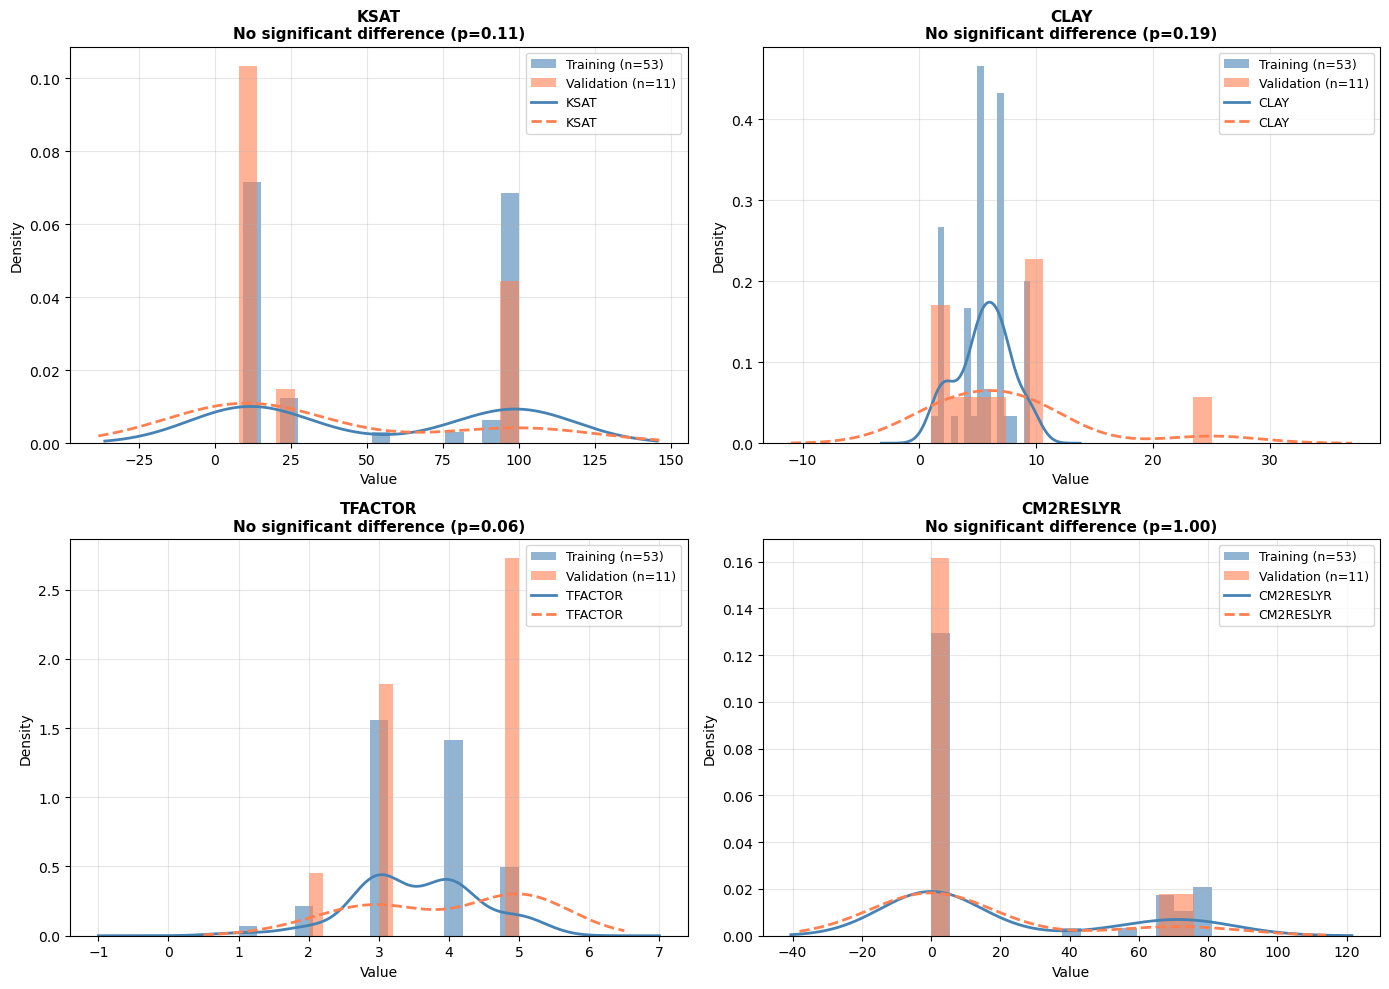


DETAILED ANALYSIS: KEY SOIL FEATURES

KSAT:
  Training:   Mean=53.51, Median=23.29, Range=[9.17, 100.00]
  Validation: Mean=34.86, Median=10.00, Range=[7.76, 100.00]
  KS test: p-value=0.11 ✓ No significant difference

CLAY:
  Training:   Mean=5.55, Median=5.40, Range=[1.00, 9.50]
  Validation: Mean=7.55, Median=7.00, Range=[1.00, 25.00]
  KS test: p-value=0.19 ✓ No significant difference

TFACTOR:
  Training:   Mean=3.55, Median=4.00, Range=[1.00, 5.00]
  Validation: Mean=4.00, Median=5.00, Range=[2.00, 5.00]
  KS test: p-value=0.06 ✓ No significant difference

CM2RESLYR:
  Training:   Mean=20.92, Median=0.00, Range=[0.00, 81.00]
  Validation: Mean=12.91, Median=0.00, Range=[0.00, 76.00]
  KS test: p-value=1.00 ✓ No significant difference


KEY FINDING

⚠ 3 feature(s) differ significantly between training and validation:

  - SLOPE_1: p=0.04
  - KFACTWS: p=0.05
  - PHWATER: p=0.02

If KSAT, CLAY, TFACTOR, or CM2RESLYR show differences,
this likely explains why that soil type is missi

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load data
train_df = pd.read_csv('typology-training-labeled.csv')
val_df = pd.read_csv('validation-labeled.csv')

# Focus on the key soil features that define the missing riparian type
key_features = ['KSAT', 'CLAY', 'TFACTOR', 'CM2RESLYR']
all_features = ['TFACTOR', 'AWS100', 'AWS25', 'DEP2WATTBL', 'SLOPE_1', 'CM2RESLYR', 
                'KFACTWS', 'PHWATER', 'CLAY', 'KSAT', 'OM', 'SAND', 'Land_Cover_Encoded']

print("="*100)
print("DISTRIBUTION COMPARISON: TRAINING vs. VALIDATION DATASETS")
print("="*100 + "\n")

# Statistical test for each feature using Kolmogorov-Smirnov test
print(f"{'Feature':<20} {'Train Mean':<15} {'Val Mean':<15} {'KS Stat':<12} {'p-value':<12} {'Significant':<15}")
print("-"*100)

ks_results = []

for feature in all_features:
    train_data = train_df[feature].dropna()
    val_data = val_df[feature].dropna()
    
    if len(train_data) > 0 and len(val_data) > 0:
        # Kolmogorov-Smirnov test (tests if distributions are different)
        ks_stat, pvalue = stats.ks_2samp(train_data, val_data)
        
        train_mean = train_data.mean()
        val_mean = val_data.mean()
        
        sig = "YES ⚠" if pvalue < 0.05 else "No ✓"
        
        print(f"{feature:<20} {train_mean:<15.2f} {val_mean:<15.2f} {ks_stat:<12.2f} {pvalue:<12.2f} {sig:<15}")
        
        ks_results.append({
            'Feature': feature,
            'Train_Mean': round(train_mean, 2),
            'Val_Mean': round(val_mean, 2),
            'KS_Statistic': round(ks_stat, 2),
            'P_Value': round(pvalue, 2),
            'Significant': 'Yes' if pvalue < 0.05 else 'No'
        })

# Export results
ks_df = pd.DataFrame(ks_results)
ks_df.to_csv('ks_test_results_train_vs_val.csv', index=False)

# ============================================================================
# VISUALIZATION: OVERLAID DISTRIBUTIONS FOR KEY FEATURES
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, feature in enumerate(key_features):
    ax = axes[idx]
    
    train_data = train_df[feature].dropna()
    val_data = val_df[feature].dropna()
    
    # Plot overlaid histograms
    ax.hist(train_data, bins=15, alpha=0.6, label=f'Training (n={len(train_data)})', color='steelblue', density=True)
    ax.hist(val_data, bins=15, alpha=0.6, label=f'Validation (n={len(val_data)})', color='coral', density=True)
    
    # Add KDE lines
    train_data.plot.kde(ax=ax, linewidth=2, color='steelblue', linestyle='-')
    val_data.plot.kde(ax=ax, linewidth=2, color='coral', linestyle='--')
    
    # Statistical info
    ks_stat, pvalue = stats.ks_2samp(train_data, val_data)
    sig_text = "SIGNIFICANT DIFFERENCE" if pvalue < 0.05 else "No significant difference"
    
    ax.set_title(f'{feature}\n{sig_text} (p={pvalue:.2f})', fontsize=11, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('key_feature_distributions_train_vs_val.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: key_feature_distributions_train_vs_val.png")
plt.show()

# ============================================================================
# DETAILED ANALYSIS: KEY SOIL FEATURES
# ============================================================================

print("\n" + "="*100)
print("DETAILED ANALYSIS: KEY SOIL FEATURES")
print("="*100 + "\n")

for feature in key_features:
    train_data = train_df[feature].dropna()
    val_data = val_df[feature].dropna()
    
    ks_stat, pvalue = stats.ks_2samp(train_data, val_data)
    
    print(f"{feature}:")
    print(f"  Training:   Mean={train_data.mean():.2f}, Median={train_data.median():.2f}, Range=[{train_data.min():.2f}, {train_data.max():.2f}]")
    print(f"  Validation: Mean={val_data.mean():.2f}, Median={val_data.median():.2f}, Range=[{val_data.min():.2f}, {val_data.max():.2f}]")
    print(f"  KS test: p-value={pvalue:.2f}", end="")
    
    if pvalue < 0.05:
        mean_diff_pct = abs(val_data.mean() - train_data.mean()) / train_data.mean() * 100
        print(f" ⚠ SIGNIFICANT DIFFERENCE ({mean_diff_pct:.2f}% difference)")
    else:
        print(f" ✓ No significant difference\n")

# ============================================================================
# SUMMARY
# ============================================================================

significant_features = ks_df[ks_df['Significant'] == 'Yes']

print("\n" + "="*100)
print("KEY FINDING")
print("="*100 + "\n")

if len(significant_features) > 0:
    print(f"⚠ {len(significant_features)} feature(s) differ significantly between training and validation:\n")
    for idx, row in significant_features.iterrows():
        print(f"  - {row['Feature']}: p={row['P_Value']:.2f}")
    print("\nIf KSAT, CLAY, TFACTOR, or CM2RESLYR show differences,")
    print("this likely explains why that soil type is missing in validation!")
else:
    print("✓ No significant differences found.")
    print("The missing type is likely due to random sampling variation, not systematic differences.")